<a href="https://colab.research.google.com/github/nicolastibata/MINE_4210_ADL_202620/blob/main/labs/Laboratorio_5/MINE_4210_ADL_202620_L5_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo ADL](https://github.com/nicolastibata/MINE_4210_ADL_202620/blob/main/docs/logo.png?raw=true)


# **Laboratorio 5.1: Segmentación Semántica de imágenes**
**Tutor: Nicolás Tibatá**

## **Tabla de Contenido**

[Contexto y objetivos](#scrollTo=9e16b05d)<br>
[1. Preparación de los datos](#scrollTo=8be75a87)<br>
[2. Modelamiento](#scrollTo=12c12dc0)<br>
[3. Evaluación](#scrollTo=e0b35595)<br>

### **Contexto y objetivos**

Este laboratorio abordará el problema de la **segmentación semántica**, que consiste en asignar a cada píxel de una imagen una etiqueta de clase. A diferencia de la detección de objetos, la segmentación ofrece un mapa preciso de las regiones de interés, con aplicaciones en:

- **Medicina**: delimitación de tumores o estructuras anatómicas en imágenes de resonancia magnética o tomografía computarizada.  
- **Agricultura de precisión**: identificación y cuantificación de cultivos y malezas en imágenes aéreas.  
- **Automoción**: segmentación de calzadas, vehículos y peatones en sistemas de conducción autónoma.  

La arquitectura **U-Net**, propuesta originalmente para segmentación biomédica en 2015, se caracteriza por su forma de "U": un **encoder** que extrae características de alto nivel y un **decoder** que recupera la resolución espacial, unidos mediante conexiones de salto (*skip connections*) para conservar detalle fino y contexto global.

**Objetivos**

1. **Construir la arquitectura U-Net** desde cero:  
   - Definición del *encoder* (bloques convolucionales y operaciones de *pooling*).  
   - Definición del *decoder* (upsampling y concatenaciones con conexiones de salto).  
2. **Configurar el entrenamiento**: función de pérdida adecuada, optimizador y métricas.  
3. **Entrenar el modelo** y analizar las curvas de pérdida y métricas para identificar sobreajuste o subajuste.  
4. **Evaluar el rendimiento** de forma cuantitativa (IoU medio, precisión de píxel) y cualitativa (visualización de máscaras superpuestas).


**Datos**  
Se empleará el dataset **Oxford-IIIT Pet**, que incluye imágenes JPG de mascotas y máscaras PNG anotadas para 37 razas distintas.

- Descarga: https://www.robots.ox.ac.uk/~vgg/data/pets/  
- Formato: imágenes + máscaras con valores de clase por píxel

In [ ]:
!pip install -q importlib_resources

import random
import logging
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfds
logging.getLogger("tensorflow_datasets").setLevel(logging.ERROR)
from tensorflow.keras.preprocessing.image import smart_resize
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

### **1. Preparación de los datos**

En esta sección se carga **Oxford-IIIT Pet**, se redimensionan imágenes y máscaras, se normalizan los valores de píxel, se recodifican las máscaras de \{1,2,3\} a \{0,1,2\}, se expande el canal de las máscaras, y se crean los splits de entrenamiento, validación de prueba (70/15/15).

In [ ]:
# Definimos nuestros parámetros
BATCH_SIZE = 16
TARGET_SIZE = (160, 160)
N_CLASSES = 3

# Cargamos la información del dataset una sola vez
print("Cargando metadatos del dataset...")
_, info = tfds.load("oxford_iiit_pet:4.*.*", with_info=True)
n_total = info.splits["train"].num_examples + info.splits["test"].num_examples

# Splits Slicing
TRAIN_SPLIT = "train+test[:70%]"
VAL_SPLIT   = "train+test[70%:85%]"
TEST_SPLIT  = "train+test[85%:]"

# Procesamiento de imagenes directo con tensorflow
def process_sample(sample):
    # Procesar Imagen
    img = sample["image"]
    img = tf.image.resize(img, TARGET_SIZE, method='bilinear')
    img = tf.cast(img, tf.float32) / 255.0

    # Procesar Máscara de Segmentación
    msk = sample["segmentation_mask"]
    msk = tf.image.resize(msk, TARGET_SIZE, method='nearest')
    # Recodificar de {1, 2, 3} a {0, 1, 2}
    mask = tf.cast(msk, tf.int32) - 1
    mask = tf.cast(mask, tf.uint8)

    return img, mask

# Creamos los pipelines de datos
def get_dataset_pipeline(split_name, is_training=True):
    # Carga directa desde TFDS
    ds = tfds.load("oxford_iiit_pet:4.*.*", split=split_name, as_supervised=False)
    ds = ds.map(process_sample, num_parallel_calls=tf.data.AUTOTUNE)

    if is_training:
        ds = ds.shuffle(1024).repeat()

    ds = ds.batch(BATCH_SIZE)
    # Dejamos los lotes listos en memoria para que la GPU no tenga que esperar
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    return ds

# Creamos los datasets listos para Keras
train_ds = get_dataset_pipeline(TRAIN_SPLIT, is_training=True)
val_ds   = get_dataset_pipeline(VAL_SPLIT, is_training=False)   # No necesita repeat ni shuffle
test_ds  = get_dataset_pipeline(TEST_SPLIT, is_training=False)  # No necesita repeat ni shuffle

# 5. Cálculo exacto de pasos por época
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)

steps_train = int(n_train // BATCH_SIZE)
steps_val   = int(n_val // BATCH_SIZE)

print(f"Configuración lista.")
print(f"Pasos por época -> Train: {steps_train}, Val: {steps_val}")


Cargando metadatos del dataset...
Configuración lista.
Pasos por época -> Train: 321, Val: 68


Antes de entrenar el modelo, debemos revisar las imágenes para verificar su calidad y la precisión de las máscaras.

Las máscaras contienen las siguientes etiquetas:

- **0**: Fondo.  
- **1**: Mascota.  
- **2**: Borde. Esta etiqueta ayuda a la red a delimitar contornos con mayor precisión.

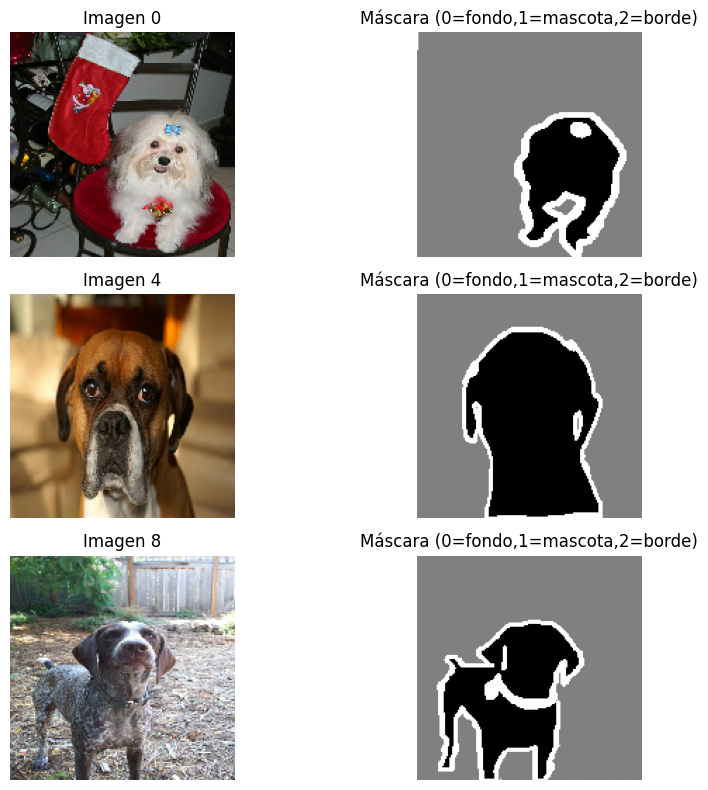

In [ ]:
# Obtenemos un lote de entrenamiento de forma correcta usando un iterador
x_batch, y_batch = next(iter(train_ds))

# Seleccionamos tres ejemplos dentro del lote
indices = [0, 4, 8]

plt.figure(figsize=(10, 8))
for i, idx in enumerate(indices):
    # Imagen original (ya está normalizada en [0,1] float32)
    ax = plt.subplot(3, 2, 2*i + 1)
    ax.imshow(x_batch[idx].numpy()) # .numpy() convierte el tensor de TF a arreglo de NumPy
    ax.set_title(f"Imagen {idx}")
    ax.axis("off")

    # Máscara correspondiente
    ax = plt.subplot(3, 2, 2*i + 2)
    ax.imshow(y_batch[idx, ..., 0].numpy(), cmap="gray") # Extraemos canal y pasamos a numpy
    ax.set_title("Máscara (0=fondo,1=mascota,2=borde)")
    ax.axis("off")

plt.tight_layout()
plt.show()


### **2. Modelamiento**


La U-Net, presentada por Ronneberger et al. en 2015 en  **"U-Net: Convolutional Networks for Biomedical Image Segmentation"** ([ver paper](https://arxiv.org/abs/1505.04597)), consiste en dos caminos:

* **Encoder (contracción)**: captura contexto global mediante convoluciones y max-pooling.
* **Decoder (expansión)**: recupera resolución espacial y refina los contornos usando upsampling y concatenaciones con las capas del encoder (*skip connections*).

> A continuación se se presenta una ilustración de la arquitectura U-Net:
>
> ![U-Net Architecture](https://miro.medium.com/v2/resize:fit:1800/1*Rmo71TyPxvLLM4FnlH5MDg.jpeg)

In [ ]:
# Realizamos nuestras dos convoluciones consecutivas con activación ReLU
def doble_conv(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)  # Primera convolución
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)  # Segunda convolución
    return x

# Creamos nuestro bloque de descenso (encoder): reduce la resolución y extrae características
def encoder_block(x, filters):
    f = doble_conv(x, filters)         # Convoluciones
    p = layers.MaxPool2D(2)(f)         # Reducción de resolución
    p = layers.Dropout(0.2)(p)         # Regularización
    return f, p                        # Retorna características y salida reducida

# Creamos nuestro bloque de ascenso (decoder): aumenta la resolución y combina características
def up_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, 3, strides=2, padding='same')(x)  # Upsampling
    x = layers.concatenate([x, skip])                                     # Conexión de salto
    x = layers.Dropout(0.2)(x)                                            # Regularización
    x = doble_conv(x, filters)                                            # Convoluciones
    return x

# Construimos nuestra U-Net
def build_unet(input_shape=(160, 160, 3), n_classes=3):
    inputs = Input(input_shape)  # Entrada del modelo

    # Encoder (menor profundidad y filtros reducidos)
    f1, c1 = encoder_block(inputs,  16)
    f2, c2 = encoder_block(c1,      32)
    f3, c3 = encoder_block(c2,      64)

    # Bottleneck
    b = doble_conv(c3, 128)

    # Decoder
    u1 = up_block(b,  f3, 64)
    u2 = up_block(u1, f2, 32)
    u3 = up_block(u2, f1, 16)

    # Capa de salida: mapa de segmentación con convolución 1×1
    outputs = layers.Conv2D(n_classes, 1, padding='same', activation='softmax')(u3)
    return Model(inputs, outputs)

# Creamos y resumimos el modelo
model = build_unet()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 160, 160,  │        448 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 160, 160,  │      2,320 │ conv2d_15[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 80, 80,    │          0 │ conv2d_16[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 80, 80,    │          0 │ max_pooling2d_3[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 80, 80,    │      4,640 │ dropout_6[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 80, 80,    │      9,248 │ conv2d_17[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 40, 40,    │          0 │ conv2d_18[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 40, 40,    │          0 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 40, 40,    │     18,496 │ dropout_7[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 40, 40,    │     36,928 │ conv2d_19[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 20, 20,    │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 20, 20,    │          0 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 20, 20,    │     73,856 │ dropout_8[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 20, 20,    │    147,584 │ conv2d_21[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 40, 40,    │     73,792 │ conv2d_22[0][0]   │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 40, 40,    │          0 │ conv2d_transpose

 Total params: 535,827 (2.04 MB)

 Trainable params: 535,827 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

**Entrenamiento del modelo**

En esta sección se compila la U-Net incluyendo, además de la exactitud, la métrica de **IoU medio**. Para la comparación con Dice, definimos una función auxiliar que se usará en la evaluación posterior.

In [ ]:
# Creamos nuestra métrica MeanIoU
class MeanIoUArgmax(tf.keras.metrics.MeanIoU):
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Convertimos probabilidades a etiquetas
        y_pred_labels = tf.argmax(y_pred, axis=-1)
        # Extraemos el canal de forma segura usando slicing clásico en lugar de squeeze
        y_true_labels = y_true[..., 0]
        return super().update_state(y_true_labels, y_pred_labels, sample_weight)

# Métrica Dice
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_ohe = tf.one_hot(tf.cast(y_true[..., 0], tf.int32), depth=N_CLASSES)
    y_pred_lbl = tf.one_hot(tf.argmax(y_pred, -1), depth=N_CLASSES)

    y_true_f = tf.reshape(y_true_ohe, [-1, N_CLASSES])
    y_pred_f = tf.reshape(y_pred_lbl, [-1, N_CLASSES])

    inter = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
    union = tf.reduce_sum(y_true_f + y_pred_f, axis=0)
    return tf.reduce_mean((2.*inter + smooth) / (union + smooth))


# Callbacks para guardar el mejor modelo y detenerse temprano
callbacks = [
    ModelCheckpoint(
        'best_unet_model.keras',
        monitor='val_loss',
        save_best_only=True
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
]

# Compilamos
model.compile(
    optimizer='rmsprop',
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        MeanIoUArgmax(num_classes=N_CLASSES, name='mean_iou'),
        dice_coef
    ]
)

# Entrenamiento
history = model.fit(
    train_ds,
    steps_per_epoch=steps_train,
    validation_data=val_ds,
    validation_steps=steps_val,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - accuracy: 0.6014 - dice_coef: 0.3156 - loss: 0.8548 - mean_iou: 0.2574 - val_accuracy: 0.6618 - val_dice_coef: 0.5122 - val_loss: 0.7521 - val_mean_iou: 0.3836
Epoch 2/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 29s 90ms/step - accuracy: 0.7011 - dice_coef: 0.5259 - loss: 0.7121 - mean_iou: 0.4065 - val_accuracy: 0.7403 - val_dice_coef: 0.5722 - val_loss: 0.6463 - val_mean_iou: 0.4490
Epoch 3/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 33s 104ms/step - accuracy: 0.7401 - dice_coef: 0.5984 - loss: 0.6433 - mean_iou: 0.4670 - val_accuracy: 0.6791 - val_dice_coef: 0.5706 - val_loss: 0.7874 - val_mean_iou: 0.4259
Epoch 4/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 39s 122ms/step - accuracy: 0.7670 - dice_coef: 0.6476 - loss: 0.5901 - mean_iou: 0.5117 - val_accuracy: 0.7884 - val_dice_coef: 0.6832 - val_loss: 0.5348 - val_mean_iou: 0.5470
Epoch 5/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 27s 83ms/step - accuracy: 0.7842 - dice_coef: 0.6758 - loss: 0.5503 - mean_iou: 0.5402 - val_a

###**3. Evaluación**


1. Evaluamos el modelo en el conjunto de prueba para obtener pérdida, exactitud y IoU medio.

2. Calculamos el coeficiente Dice y la precisión de píxel en test.

In [ ]:
# Cargamos el mejor modelo
model = load_model(
    'best_unet_model.keras',
    custom_objects={
        'MeanIoUArgmax': MeanIoUArgmax,
        'dice_coef': dice_coef
    }
)

# Evaluación cuantitativa
results = model.evaluate(
    test_ds,
    return_dict=True
)
print("Pérdida (test):     ", results['loss'])
print("Exactitud (test):   ", results['accuracy'])
print("Mean IoU (test):    ", results['mean_iou'])
print("Dice Coef (test):   ", results['dice_coef'])

# Métricas por clase usando el iterador nativo de tf.data.Dataset
smooth = 1e-6
class_dice = np.zeros(N_CLASSES, dtype=np.float32)
pixel_matches = 0
total_pixels = 0
actual_steps = 0

# Recorremos el dataset lote por lote de forma iterativa
for x_b, y_b in test_ds:
    # Convertimos los tensores a arrays de numpy para la lógica posterior
    x_b_np = x_b.numpy()
    y_true_lbl = y_b[..., 0].numpy() # Extraemos canal de la máscara de test

    # Predicción
    y_pred = model.predict(x_b_np, verbose=0)
    y_pred_lbl = np.argmax(y_pred, axis=-1)

    # Conteo de píxeles correctos
    pixel_matches += np.sum(y_pred_lbl == y_true_lbl)
    total_pixels += y_true_lbl.size

    # Acumulamos Dice por clase
    for cls in range(N_CLASSES):
        y_t = (y_true_lbl == cls).astype(np.float32).ravel()
        y_p = (y_pred_lbl == cls).astype(np.float32).ravel()
        inter = np.sum(y_t * y_p)
        union = np.sum(y_t) + np.sum(y_p)
        class_dice[cls] += (2 * inter + smooth) / (union + smooth)

    actual_steps += 1

# Cálculo final de promedios ponderados por los pasos reales procesados
pixel_acc = pixel_matches / total_pixels
dice_scores = class_dice / actual_steps

print("\n--- Resultados Detallados ---")
print("Precisión de píxel:    ", pixel_acc)
print("Dice por clase:        ", dice_scores)
print("  - Fondo (0):         ", dice_scores[0])
print("  - Mascota (1):       ", dice_scores[1])
print("  - Borde (2):         ", dice_scores[2])
print("Dice medio:            ", dice_scores.mean())


265/265 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.8768 - dice_coef: 0.7975 - loss: 0.3212 - mean_iou: 0.6867
Pérdida (test):      0.3211507201194763
Exactitud (test):    0.8768376111984253
Mean IoU (test):     0.6867411732673645
Dice Coef (test):    0.7974681258201599

--- Resultados Detallados ---
Precisión de píxel:     0.8768376736111111
Dice por clase:         [0.86768526 0.92812866 0.5965916 ]
  - Fondo (0):          0.86768526
  - Mascota (1):        0.92812866
  - Borde (2):          0.5965916
Dice medio:             0.7974685


**Predicción / Inferencia**

Visualizamos algunos ejemplos de test, comparando la imagen, la máscara real y la predicción, para apreciar la calidad de la segmentación.

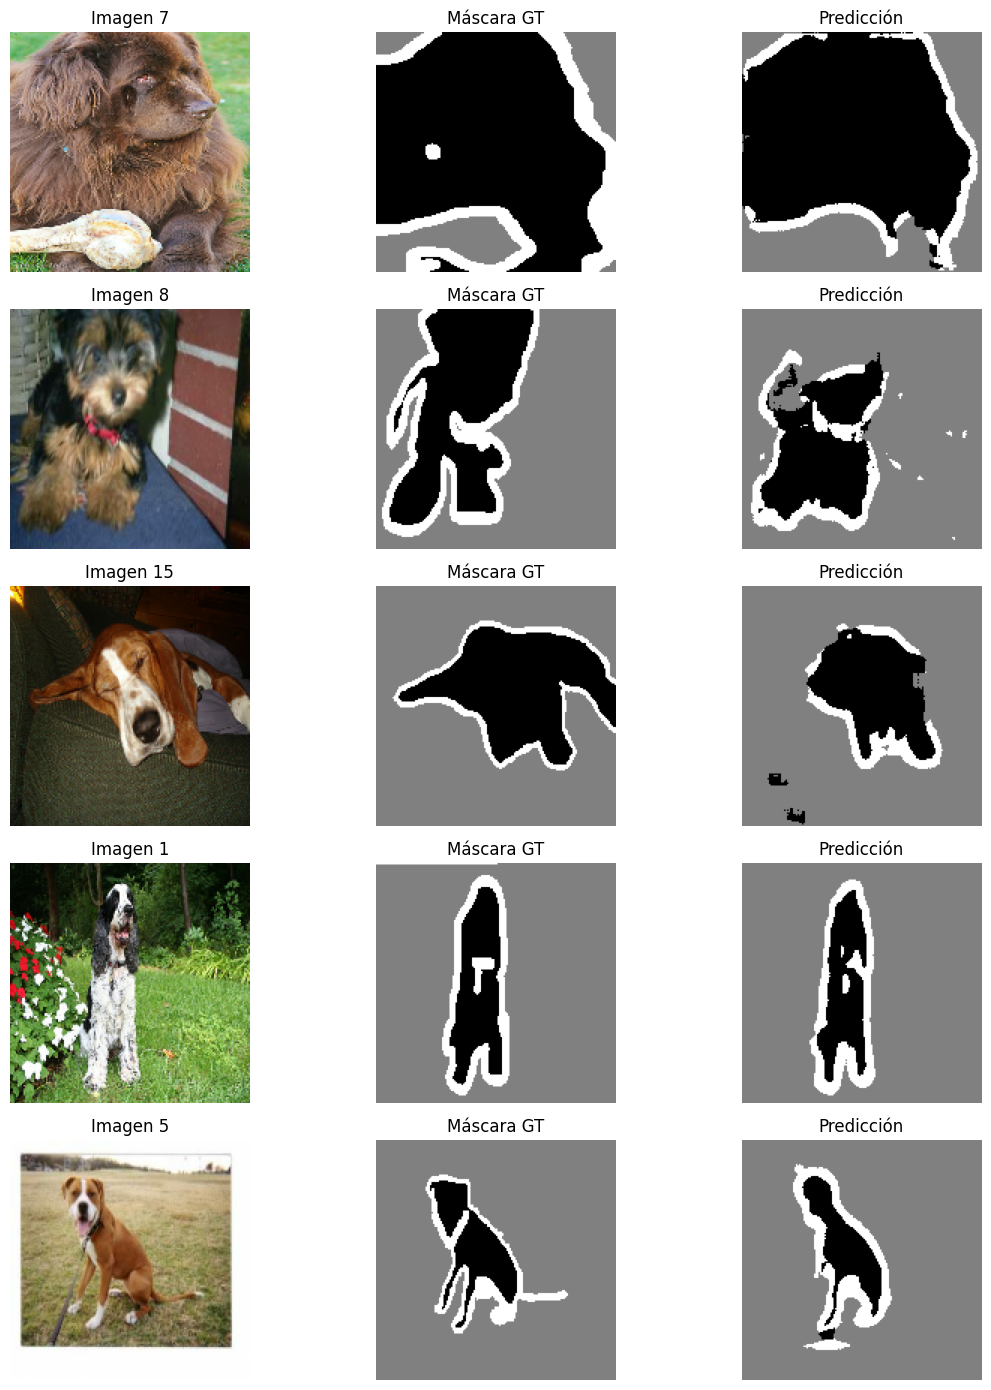

In [ ]:
# Obtenemos un lote del dataset de prueba de forma correcta
x_batch, y_batch = next(iter(test_ds))

# Convertimos los tensores del lote a arreglos de numpy
x_batch_np = x_batch.numpy()
y_batch_np = y_batch.numpy()

# Elegimos 5 índices aleatorios dentro del batch (máximo tamaño del BATCH_SIZE)
indices = random.sample(range(x_batch_np.shape[0]), 5)

plt.figure(figsize=(12, 14))
for i, idx in enumerate(indices):
    img = x_batch_np[idx]
    ygt = y_batch_np[idx, ..., 0]

    ypr_prob = model.predict(img[np.newaxis, ...], verbose=0)
    ypr = np.argmax(ypr_prob, axis=-1)[0]

    # Imagen original
    ax = plt.subplot(5, 3, 3*i + 1)
    ax.imshow(img)
    ax.set_title(f'Imagen {idx}')
    ax.axis('off')

    # Máscara real (Ground Truth)
    ax = plt.subplot(5, 3, 3*i + 2)
    ax.imshow(ygt, cmap='gray')
    ax.set_title('Máscara GT')
    ax.axis('off')

    # Máscara predicha por la U-Net
    ax = plt.subplot(5, 3, 3*i + 3)
    ax.imshow(ypr, cmap='gray')
    ax.set_title('Predicción')
    ax.axis('off')

plt.tight_layout()
plt.show()
